# A timestamp audit of filing-tone signals

*An integrated Jupyter research report demonstrating Pathway 1 of the final project.*

## Abstract

Financial language models can classify sentiment more accurately than simple word lists, but a
better text classifier does not necessarily produce a better financial decision. This known-truth
study constructs 1,200 synthetic filings with a 45-day publication lag, a tone-related
announcement return, and a weaker post-publication drift. It compares a transparent finance-style
lexicon with a richer text-reader proxy on the final 30 percent of the dated sample. Aligning the
score to the fiscal period end produces an information coefficient of 0.548 because the outcome
improperly includes the announcement response; aligning it to the filing date reduces the
coefficient to 0.106. On the honest later sample, the richer reader records an IC of 0.140 versus
0.136 for the lexicon. The warranted conclusion is methodological: timestamp discipline matters
more here than model complexity. Synthetic data and an offline model proxy prevent any claim
about actual SEC filings or FinBERT profitability.

## Introduction

Company filings contain language that may help investors and creditors assess firms. A contextual
model may read that language better than a word list, but the downstream question is narrower:
does its score improve a decision using information available at the decision time? This report
asks whether a richer filing-tone reader ranks returns **after the filing is public** better than a
simple finance-style lexicon once the filing timestamp and a declared trading cost are respected.

The intended decision is to rank newly public filings and form top-minus-bottom positions after
publication. The contribution is an audit of the research design, not a new trading strategy: the
known-truth experiment isolates an inadmissible period-end alignment and separates text-reading
quality from downstream return predictability.

## Related literature

Tetlock (2007) provides an early finance example linking quantified language to market outcomes.
Loughran and McDonald (2011) show why financial text requires a domain-specific dictionary, and
Jegadeesh and Wu (2013) show that word weighting can materially affect measured tone. Together,
they motivate a transparent but explicitly modeled lexicon baseline. Araci (2019) and Huang, Wang, and Yang
(2023) show that finance-adapted contextual models can improve financial sentiment-classification
tasks. Those findings do not establish that better sentiment labels produce better return
forecasts. Cohen, Malloy, and Nguyen (2020) provide evidence that changes in filing language are
associated with later corporate outcomes and returns, making the downstream question plausible.

This example asks a narrower design question: after a filing is public, does the complex reader
improve a feasible return-ranking decision relative to a finance-specific lexicon? Because the
data are synthetic, the notebook demonstrates the comparison and timing failure mode; it does not
replicate the historical findings. The development literature map is in `LITERATURE_MAP.md`, and
complete references appear at the end of the notebook.


## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import _pipeline as P            # shared data + models (see _pipeline.py)

FIG = "figures"
import os; os.makedirs(FIG, exist_ok=True)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
GREEN, RED, GREY, BLUE = "#2e7d32", "#c62828", "#888888", "#1565c0" 

## 1. The data (and the truth we planted)

Each synthetic filing has a latent **tone**. Two returns follow it:
an **announcement** jump at the filing date (strongly tone-driven — the market reacts to the
news, and you could *not* have traded it beforehand), and a faint **post-filing drift** over
the next 20 days (weakly tone-driven — the only thing genuinely predictable *after* the
information is public). The filing is dated 45 days after the period it describes.

In [2]:
d = P.make_filings(n=1200)
print("a filing:", d["text"][0][:160], "...")
print(f"planted tone = {d['tone'][0]:+.2f}   announcement = {d['announcement'][0]:+.3f}   drift = {d['drift'][0]:+.3f}")
print(f"period end (day) = {d['period_end'][0]}, filed (day) = {d['filing_date'][0]}  (45-day lag)")

a filing: Revenue declined sharply. Margins expanded this quarter. Free cash flow deteriorated. We raised full-year guidance. Free cash flow deteriorated. Margins compres ...
planted tone = +0.78   announcement = +0.030   drift = -0.005
period end (day) = 0, filed (day) = 45  (45-day lag)


## 2. Two readers of the text

- **Baseline** — a shallow Loughran-McDonald-style lexicon: net (positive − negative) hits.
- **Model** — **FinBERT** if `transformers`+`torch` are installed; otherwise a deterministic
  text-reader stand-in so this notebook always runs. Install the two packages to use the
  real model.

In [3]:
lexicon = P.lexicon_score(d["text"])
finbert, backend = P.finbert_score(d["text"])
candidate_label = "FinBERT" if backend.startswith("FinBERT") else "richer reader proxy"
print("sentiment backend:", backend)

sentiment backend: lexicon stand-in (install transformers+torch for real FinBERT)


## 3. The leakage trap — which date do you align to?

The tempting mistake is to align the filing's tone to the return starting at the **period
end**. That window swallows the **announcement** move — a return you could not have captured
before the filing was public. Aligning to the **filing date** (post-filing drift only) is the
honest, tradeable target. Watch the information coefficient collapse when we stop cheating.

IC(richer reader proxy, period-end label)  = +0.548   <- leakage: the announcement you couldn't trade
IC(richer reader proxy, filing-date label) = +0.106   <- honest, tradeable


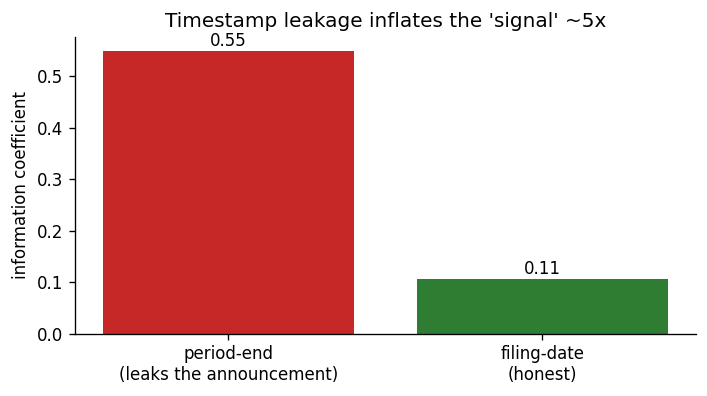

In [4]:
leaked  = d["announcement"] + d["drift"]     # period-end as-of: includes the announcement pop
correct = d["drift"]                          # filing-date as-of: only post-public drift

ic_leak = P.rank_ic(finbert, leaked)
ic_true = P.rank_ic(finbert, correct)
print(f"IC({candidate_label}, period-end label)  = {ic_leak:+.3f}   <- leakage: the announcement you couldn't trade")
print(f"IC({candidate_label}, filing-date label) = {ic_true:+.3f}   <- honest, tradeable")

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.bar(["period-end\n(leaks the announcement)", "filing-date\n(honest)"], [ic_leak, ic_true],
       color=[RED, GREEN])
ax.set_ylabel("information coefficient"); ax.set_title("Timestamp leakage inflates the 'signal' ~5x")
for i, v in enumerate([ic_leak, ic_true]): ax.text(i, v + 0.01, f"{v:.2f}", ha="center")
fig.tight_layout(); fig.savefig(f"{FIG}/01_leakage.png", bbox_inches="tight"); plt.show()

## 4. Research design and time-aware evaluation

The baseline is the shallow lexicon and the candidate is the richer reader. Neither is fitted on
these records, so the first 70 percent serves only as the earlier development region and the final
30 percent supplies the later comparison. We never shuffle time. The primary metric is rank
information coefficient. The secondary decision ledger is a top-minus-bottom **tercile spread**
of post-filing drift, net of 10 basis points on each leg. No hyperparameter search is conducted.

The period-end label is a failure control, not an eligible model: it deliberately includes an
announcement response that the post-publication decision could not have captured. The original
example predates the course research-record convention, so its plan was not frozen before the
results. `RESEARCH_RECORD.md` discloses that defect rather than inventing a preregistration.

reader               OOS IC   net tercile spread
richer reader proxy   +0.140              +0.0022
lexicon baseline     +0.136              +0.0014


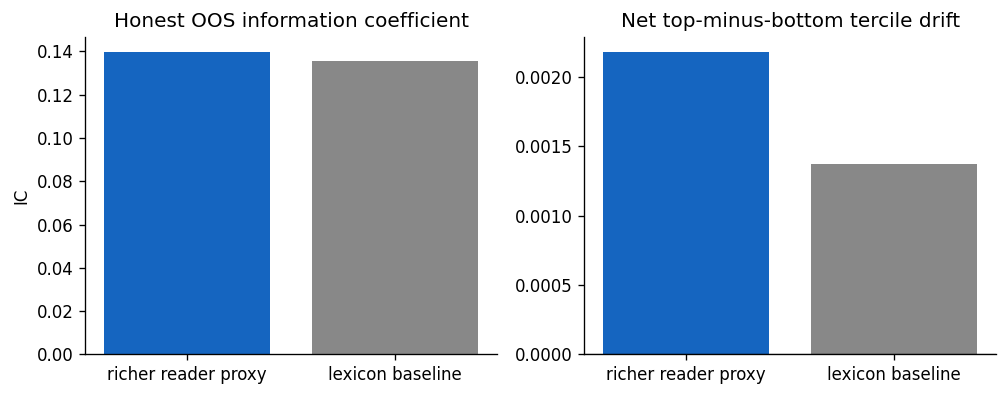

In [5]:
n = len(correct); oos = slice(int(0.7 * n), n)

def tercile_spread(score, fut, cost_bps=10.0):
    hi, lo = np.quantile(score, 2/3), np.quantile(score, 1/3)
    spread = fut[score >= hi].mean() - fut[score <= lo].mean()
    return spread - 2 * cost_bps / 1e4        # long + short = 2 legs of cost

rows = []
for name, s in [(candidate_label, finbert), ("lexicon baseline", lexicon)]:
    rows.append((name, P.rank_ic(s[oos], correct[oos]), tercile_spread(s[oos], correct[oos])))
print(f"{'reader':18} {'OOS IC':>8} {'net tercile spread':>20}")
for name, ic, sp in rows:
    print(f"{name:18} {ic:>+8.3f} {sp:>+20.4f}")

fig, ax = plt.subplots(1, 2, figsize=(8.5, 3.4))
labels = [r[0] for r in rows]
ax[0].bar(labels, [r[1] for r in rows], color=[BLUE, GREY]); ax[0].set_title("Honest OOS information coefficient")
ax[0].set_ylabel("IC")
ax[1].bar(labels, [r[2] for r in rows], color=[BLUE, GREY]); ax[1].set_title("Net top-minus-bottom tercile drift")
ax[1].axhline(0, color="k", lw=0.7)
fig.tight_layout(); fig.savefig(f"{FIG}/02_finbert_vs_lexicon.png", bbox_inches="tight"); plt.show()

## 5. Results and decision interpretation

**Decision layer.** Sort filings by sentiment; go long the top tercile, short the bottom,
rebalanced per filing. The number that matters is the tercile spread **net of costs**.

**Result.** Removing the timestamp leak cuts the apparent signal by roughly 5×. On the
honest, post-filing target the richer reader's edge is small and does not clearly beat the
shallow lexicon. The available point estimates do not include enough uncertainty evidence to
treat that difference as stable. This is a useful negative result: the easy apparent "NLP
alpha" was primarily a timing artifact in this known-truth experiment.

## 6. Robustness and alternative explanations

The strongest robustness check changes only the target clock: removing the announcement return
sharply reduces the measured association. A full empirical study would also prespecify subperiod,
sector, alternative-horizon, cost, and seed sensitivities while preserving an untouched final
test. The richer proxy may simply encode more of the planted vocabulary rather than context, and
the small final-block difference may be sampling variation. This experiment does not distinguish
those explanations.

## 7. Limitations

- **Synthetic data.** Real filings have richer language and messier timestamps; this experiment
  provides no estimate of return predictability in actual EDGAR data.
- **Offline candidate proxy.** The committed output uses a deterministic richer lexicon when the
  optional transformer packages are absent, so it cannot support a claim about FinBERT itself.
- **One universe, one horizon.** No cross-sectional controls (sector, size), no multiple
  horizons; the tercile spread is a single cut.
- **Costs are a stylized 10 bp.** Real market-impact for a filing-driven strategy that
  concentrates around filing dates would likely be worse.
- **No multiple-testing accounting.** We compared two readers; a real search across models,
  lexicons, and horizons would need a deflated Sharpe / trial count.

## 8. Conclusion

The interesting question was never whether a language model sounds fluent. It was whether the
score improves a return decision that could actually have been made after publication. Here the
incremental difference is slight, while the timestamp error is large. Better language
representation and better financial evidence are separate achievements.

## References

- Araci, D. (2019). *FinBERT: Financial Sentiment Analysis with Pre-trained Language Models*.
  arXiv:1908.10063. https://doi.org/10.48550/arXiv.1908.10063
- Cohen, L., Malloy, C., and Nguyen, Q. (2020). "Lazy Prices." *The Journal of Finance*,
  75(3), 1371–1415. https://doi.org/10.1111/jofi.12885
- Huang, A. H., Wang, H., and Yang, Y. (2023). "FinBERT: A Large Language Model for Extracting
  Information from Financial Text." *Contemporary Accounting Research*, 40(2), 806–841.
  https://doi.org/10.1111/1911-3846.12832
- Jegadeesh, N., and Wu, D. (2013). "Word Power: A New Approach for Content Analysis."
  *Journal of Financial Economics*, 110(3), 712–729.
  https://doi.org/10.1016/j.jfineco.2013.08.018
- Loughran, T., and McDonald, B. (2011). "When Is a Liability Not a Liability? Textual Analysis,
  Dictionaries, and 10-Ks." *The Journal of Finance*, 66(1), 35–65.
  https://doi.org/10.1111/j.1540-6261.2010.01625.x
- Tetlock, P. C. (2007). "Giving Content to Investor Sentiment: The Role of Media in the Stock
  Market." *The Journal of Finance*, 62(3), 1139–1168.
  https://doi.org/10.1111/j.1540-6261.2007.01232.x

## Reproducibility and AI-use disclosure

`_pipeline.py` generates the data and metrics with seed `20260718`. Core dependencies are NumPy
and Matplotlib; Transformers and PyTorch are optional. This is a course-authored worked example.
Students must follow the course AI-use policy, verify their own citations, and write their own
analysis and conclusions.